In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import plotly.express as px
import plotly.graph_objects as go
from branca.colormap import LinearColormap
import folium
from matplotlib import cm, colors
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/global-earthquake-tsunami-risk-assessment-dataset/earthquake_data_tsunami.csv


## 🌍 Global Earthquake and Tsunami Risk Assessment Dataset

## Description:
This dataset provides comprehensive global data on earthquake and tsunami risks, integrating historical seismic activity, tectonic plate boundaries, oceanic fault lines, and coastal vulnerability indicators. It includes parameters such as earthquake magnitude, depth, frequency, tsunami height, affected population density, infrastructure exposure, and hazard zones. The dataset is valuable for disaster risk modeling, early warning system development, climate resilience planning, and geospatial analytics. Ideal for researchers, data scientists, and policymakers aiming to assess, visualize, and mitigate natural disaster impacts globally.

## Import Data set

In [2]:
df = pd.read_csv("/kaggle/input/global-earthquake-tsunami-risk-assessment-dataset/earthquake_data_tsunami.csv")

In [3]:
df.head()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1


In [4]:
df.tail()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
777,7.7,0,8,912,427,0.0,0.0,60.0,13.0490,-88.660,2001,1,0
778,6.9,5,7,745,0,0.0,0.0,36.4,56.7744,-153.281,2001,1,0
779,7.1,0,7,776,372,0.0,0.0,103.0,-14.9280,167.170,2001,1,0
780,6.8,0,5,711,64,0.0,0.0,33.0,6.6310,126.899,2001,1,0
781,7.5,0,7,865,324,0.0,0.0,33.0,6.8980,126.579,2001,1,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  782 non-null    float64
 1   cdi        782 non-null    int64  
 2   mmi        782 non-null    int64  
 3   sig        782 non-null    int64  
 4   nst        782 non-null    int64  
 5   dmin       782 non-null    float64
 6   gap        782 non-null    float64
 7   depth      782 non-null    float64
 8   latitude   782 non-null    float64
 9   longitude  782 non-null    float64
 10  Year       782 non-null    int64  
 11  Month      782 non-null    int64  
 12  tsunami    782 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 79.6 KB


In [6]:
df.dtypes

magnitude    float64
cdi            int64
mmi            int64
sig            int64
nst            int64
dmin         float64
gap          float64
depth        float64
latitude     float64
longitude    float64
Year           int64
Month          int64
tsunami        int64
dtype: object

In [7]:
df.describe()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,6.941125,4.333760,5.964194,870.108696,230.250639,1.325757,25.038990,75.883199,3.538100,52.609199,2012.280051,6.563939,0.388747
std,0.445514,3.169939,1.462724,322.465367,250.188177,2.218805,24.225067,137.277078,27.303429,117.898886,6.099439,3.507866,0.487778
min,6.500000,0.000000,1.000000,650.000000,0.000000,0.000000,0.000000,2.700000,-61.848400,-179.968000,2001.000000,1.000000,0.000000
25%,6.600000,0.000000,5.000000,691.000000,0.000000,0.000000,14.625000,14.000000,-14.595600,-71.668050,2007.000000,3.250000,0.000000
50%,6.800000,5.000000,6.000000,754.000000,140.000000,0.000000,20.000000,26.295000,-2.572500,109.426000,2013.000000,7.000000,0.000000
75%,7.100000,7.000000,7.000000,909.750000,445.000000,1.863000,30.000000,49.750000,24.654500,148.941000,2017.000000,10.000000,1.000000
max,9.100000,9.000000,9.000000,2910.000000,934.000000,17.654000,239.000000,670.810000,71.631200,179.662000,2022.000000,12.000000,1.000000


In [8]:
df.shape

(782, 13)

In [9]:
df.isnull().sum()

magnitude    0
cdi          0
mmi          0
sig          0
nst          0
dmin         0
gap          0
depth        0
latitude     0
longitude    0
Year         0
Month        0
tsunami      0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.nunique()

magnitude     24
cdi           10
mmi            9
sig          339
nst          312
dmin         369
gap          256
depth        303
latitude     778
longitude    777
Year          22
Month         12
tsunami        2
dtype: int64

In [12]:
df.describe().loc[['mean', 'max','min']]

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
mean,6.941125,4.33376,5.964194,870.108696,230.250639,1.325757,25.03899,75.883199,3.5381,52.609199,2012.280051,6.563939,0.388747
max,9.100000,9.00000,9.000000,2910.000000,934.000000,17.654000,239.00000,670.810000,71.6312,179.662000,2022.000000,12.000000,1.000000
min,6.500000,0.00000,1.000000,650.000000,0.000000,0.000000,0.00000,2.700000,-61.8484,-179.968000,2001.000000,1.000000,0.000000


In [13]:
df.columns

Index(['magnitude', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap', 'depth',
       'latitude', 'longitude', 'Year', 'Month', 'tsunami'],
      dtype='object')

## Data visualizations

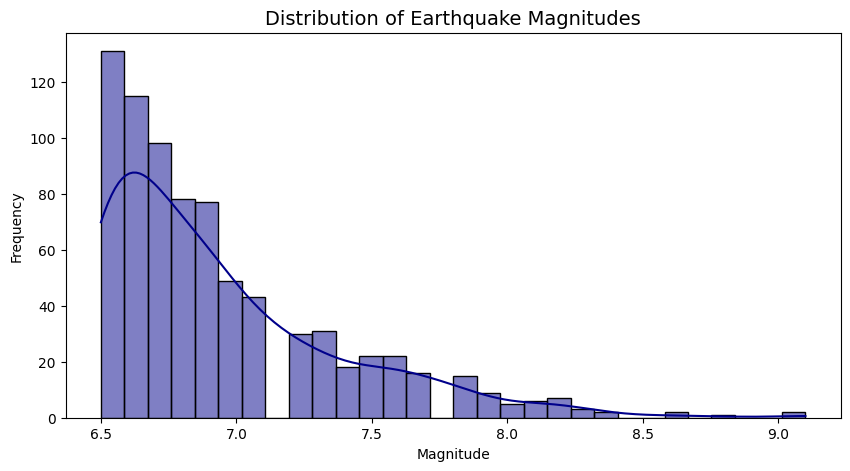

In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(df['magnitude'], bins=30, kde=True, color='darkblue')
plt.title('Distribution of Earthquake Magnitudes', fontsize=14)
plt.xlabel('Magnitude')
plt.ylabel('Frequency')
plt.show()


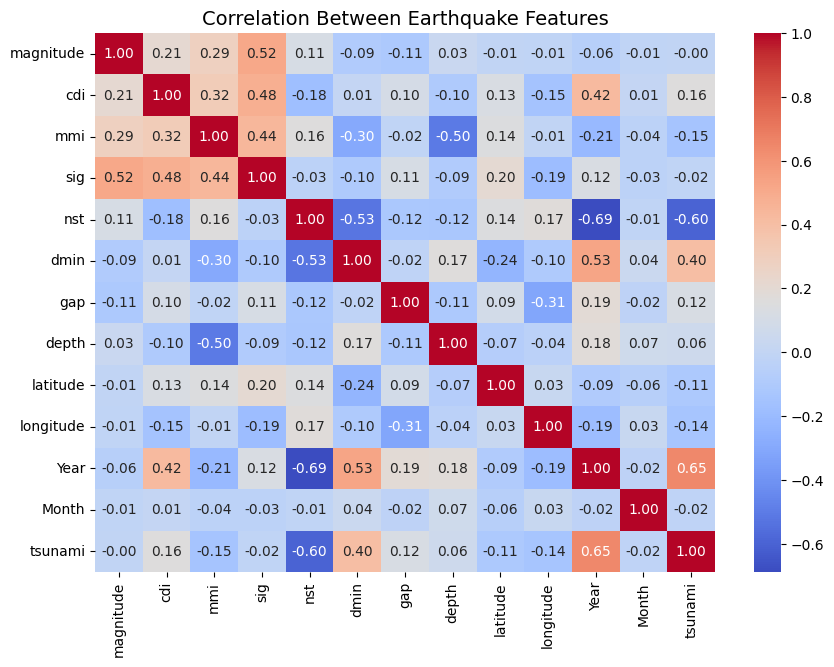

In [15]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Earthquake Features', fontsize=14)
plt.show()

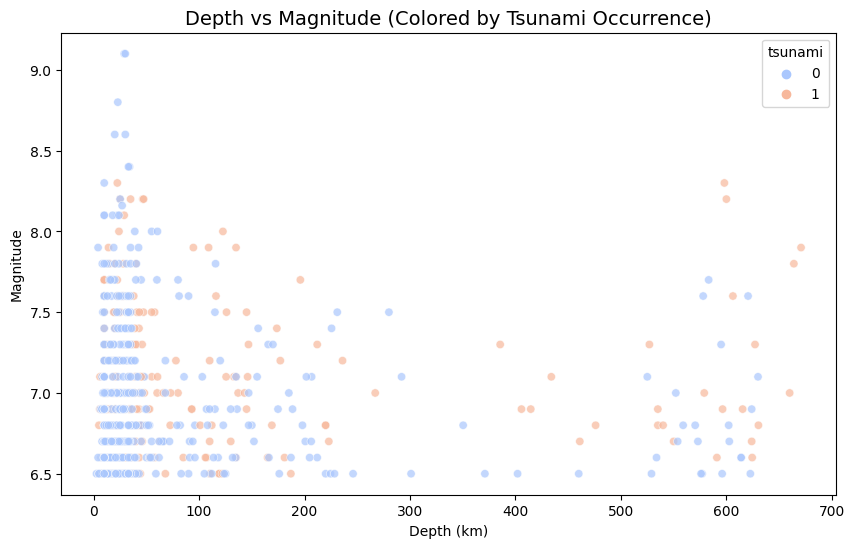

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='depth', y='magnitude', hue='tsunami', data=df, palette='coolwarm', alpha=0.7)
plt.title('Depth vs Magnitude (Colored by Tsunami Occurrence)', fontsize=14)
plt.xlabel('Depth (km)')
plt.ylabel('Magnitude')
plt.show()

In [17]:
import plotly.express as px

In [18]:
fig = px.scatter_geo(
    df,
    lat='latitude',
    lon='longitude',
    color='magnitude',
    size='magnitude',
    hover_name='Year',
    title='Global Earthquake Distribution (by Magnitude)',
    projection='natural earth',
    color_continuous_scale='Inferno'
)
fig.show()


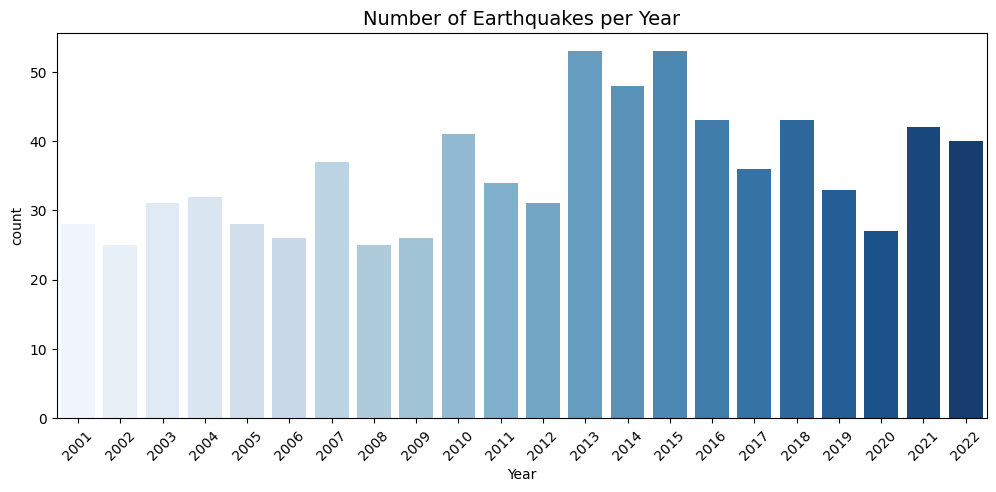

In [19]:
plt.figure(figsize=(12, 5))
sns.countplot(x='Year', data=df, palette='Blues')
plt.title('Number of Earthquakes per Year', fontsize=14)
plt.xticks(rotation=45)
plt.show()

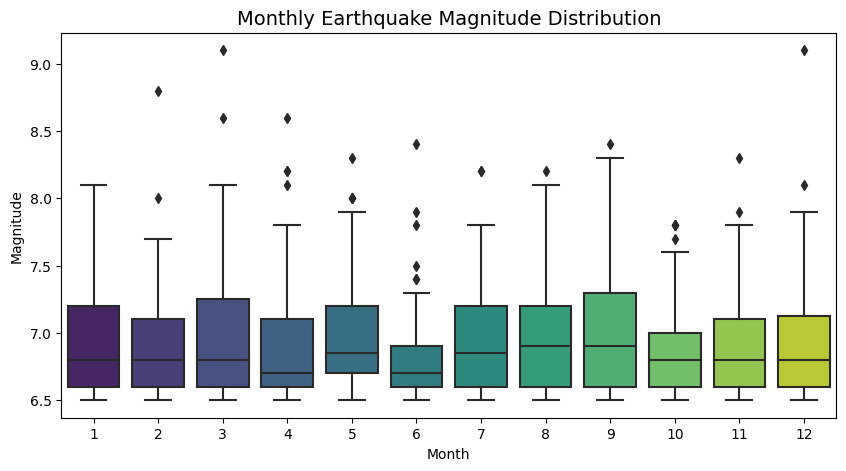

In [20]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Month', y='magnitude', data=df, palette='viridis')
plt.title('Monthly Earthquake Magnitude Distribution', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Magnitude')
plt.show()

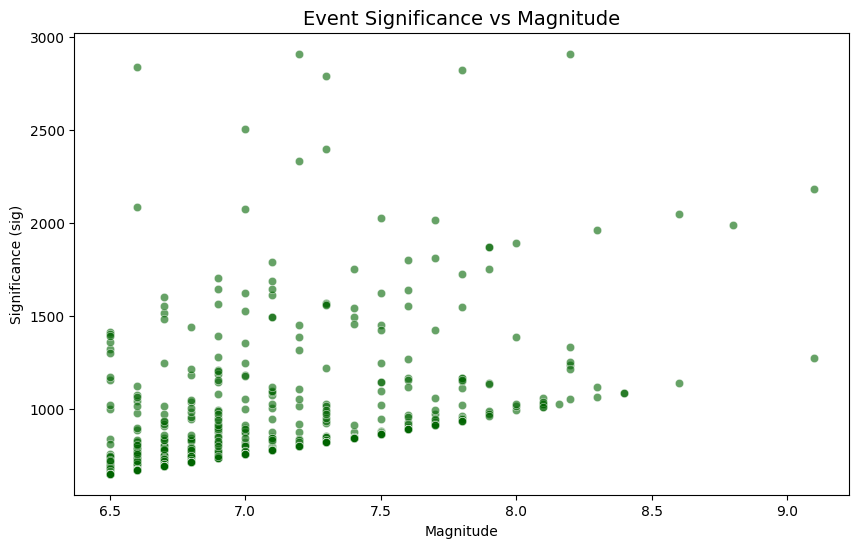

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='magnitude', y='sig', data=df, color='darkgreen', alpha=0.6)
plt.title('Event Significance vs Magnitude', fontsize=14)
plt.xlabel('Magnitude')
plt.ylabel('Significance (sig)')
plt.show()

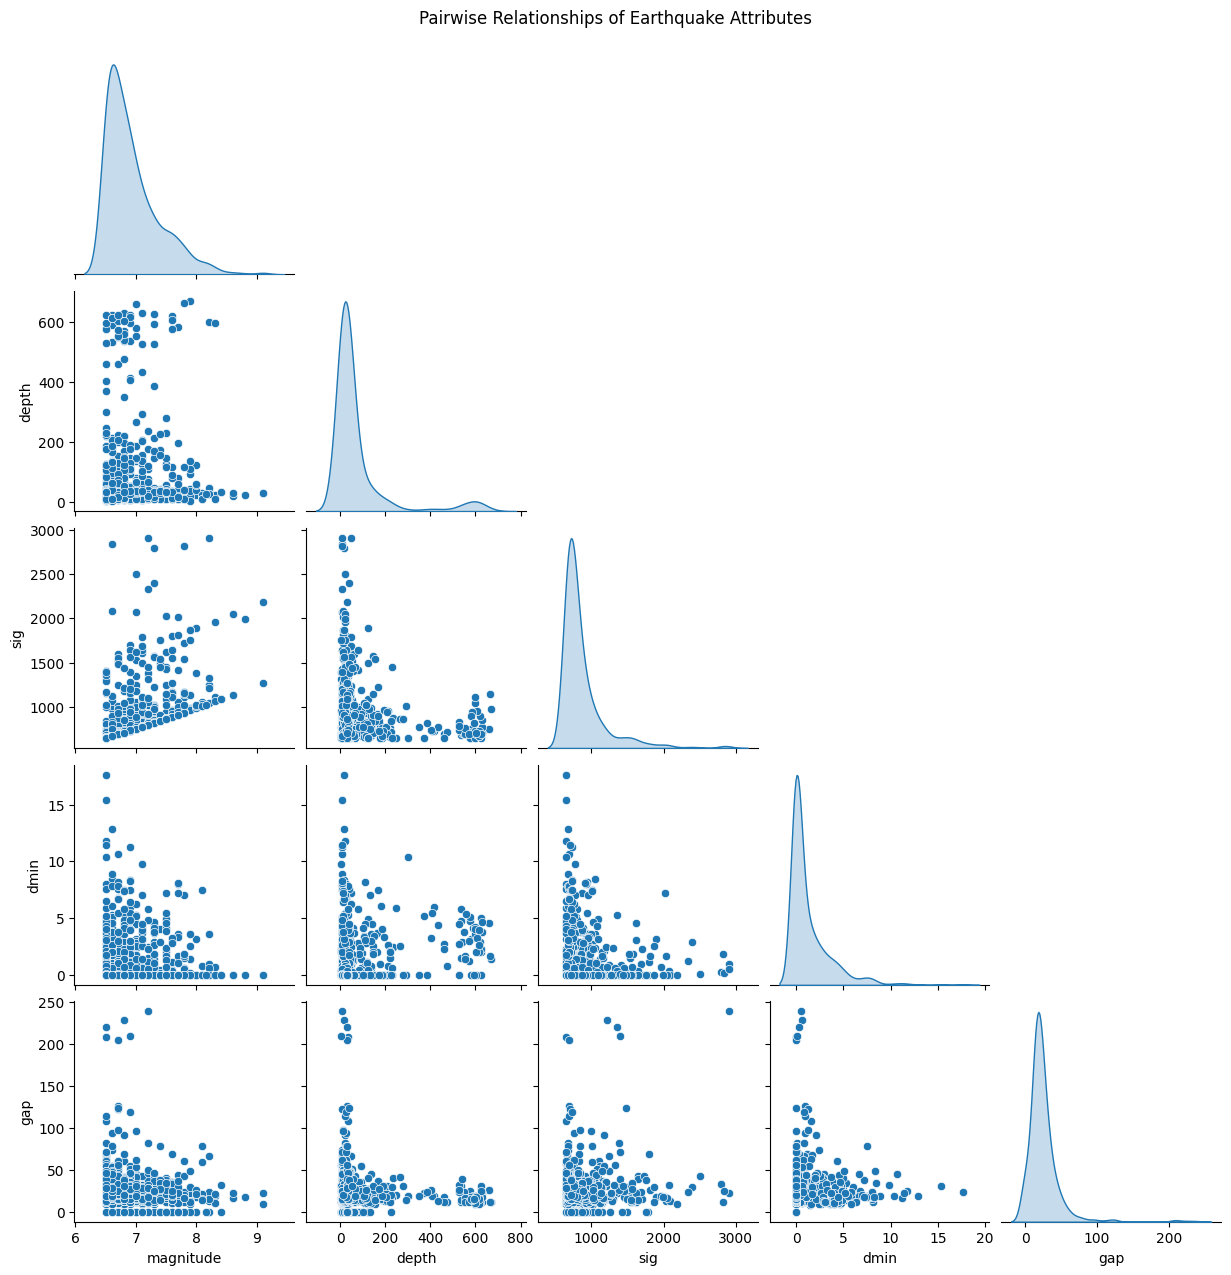

In [22]:
sns.pairplot(df[['magnitude', 'depth', 'sig', 'dmin', 'gap']], diag_kind='kde', corner=True)
plt.suptitle('Pairwise Relationships of Earthquake Attributes', y=1.02)
plt.show()

## ML Algorithms

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [24]:
df = df.dropna()
X = df[['magnitude', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap', 'depth', 'latitude', 'longitude', 'Year', 'Month']]
y = df['tsunami']

In [25]:
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC()
}

In [28]:
accuracies = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds) * 100
    accuracies[name] = acc
    print(f"{name} Accuracy: {acc:.2f}%")

Logistic Regression Accuracy: 80.25%
Decision Tree Accuracy: 91.08%
Random Forest Accuracy: 91.72%
Gradient Boosting Accuracy: 96.18%
K-Nearest Neighbors Accuracy: 84.08%
Support Vector Machine Accuracy: 82.17%


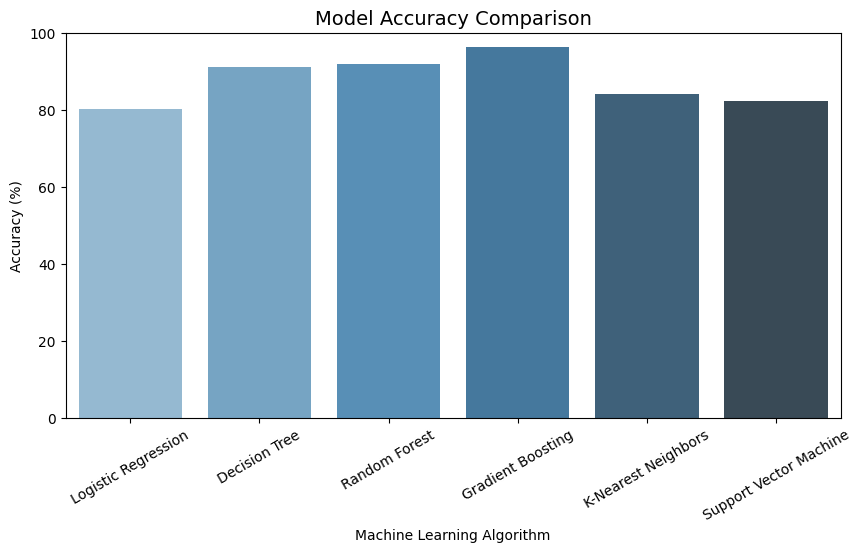

In [29]:
plt.figure(figsize=(10, 5))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette='Blues_d')
plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.xlabel('Machine Learning Algorithm')
plt.xticks(rotation=30)
plt.ylim(0, 100)
plt.show()

## Thank you...pls upvote!!!!